In [1]:
import numpy as np
import matplotlib.pyplot as plt
import load_mnist

In [2]:
# load data using functions coded in load_mnist.py
y_train = load_mnist.load_labels(load_mnist.f_training_labels)
X_train = np.hstack((load_mnist.load_images(load_mnist.f_training_images), np.ones((len(y_train),1))))/255.0

y_test = load_mnist.load_labels(load_mnist.f_test_labels)
X_test = np.hstack((load_mnist.load_images(load_mnist.f_test_images), np.ones((len(y_test),1))))/255.0

In [14]:
def train_svm_sgd(X, y, lam, n_batch, a, steps):
    """Stochastic gradient descent algorithm for classifying handwritten digits
    
    Randomly selects n_batch records from the training data and processes as a minibatch. 
    
    """
    
    # parameters for SVM-SGD algorithm
    n_total = len(y)    
    
    w = np.zeros((len(X_train[0]),10))
    
    for k in range(steps):
       
        # randomly choose indices from the original data for the minibatch
        minibatch_indices = np.random.randint(0, n_total, n_batch)
        X_batch = X_train[minibatch_indices]
        y_batch = load_mnist.digit_2_matrix(y_train[minibatch_indices])

        # diminishing tau
        tau = 1/np.sqrt(a*(k+1))

        # calculate the indicator value
        dxw = np.multiply(y_batch, X_batch@w)    

        # calculate the gradient -- the boolean operation evaluates to 0,1
        grad_sum = -np.multiply(dxw.T<1, y_batch.T)@X_batch

        w_new = w - tau * (grad_sum.T + 2*lam/(n_total/n_batch)*w)
        w = w_new
    
    return w

# Test performance with $10^{-1} \leq a \leq 10^{1}$

In [15]:
a_arr = np.logspace(-2,5,10)
steps_arr = np.array([100, 1000, 10000])

err_test = np.zeros((len(a_arr),len(steps_arr)))

# loop 100 times to average results
for counter in range(100):
    
    for i, a in enumerate(a_arr):
        
        for j, steps in enumerate(steps_arr):

            # train the model using the training set
            w = train_svm_sgd(X_train, y_train, 1, 50, a, steps)

            # use the test set to measure error
            y_hat = load_mnist.matrix_2_digit(X_test@w)
            err_test[i,j] += 1 - np.sum(y_hat==y_test) / len(y_test)

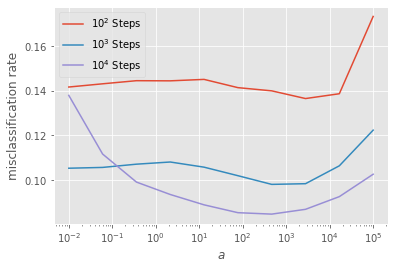

In [17]:
plt.plot(a_arr, err_test[:,0]/100, label=r'$10^2$ Steps')
plt.plot(a_arr, err_test[:,1]/100, label=r'$10^3$ Steps')
plt.plot(a_arr, err_test[:,2]/100, label=r'$10^4$ Steps')

plt.xlabel(r'$a$')
plt.ylabel('misclassification rate')

plt.semilogx()
plt.legend()